# Activation Functions and the Vanishing Gradient Problem in Deep Neural Networks

## Aim of this Notebook

This notebook investigates how different activation functions influence the training behaviour of deep neural networks. In particular, sigmoid, tanh and ReLU activation functions are compared to understand their effect on gradient propagation, convergence speed and classification accuracy.

## Dataset Selection

The Fashion-MNIST dataset is used in this experiment. It consists of grayscale images representing different categories of clothing such as shirts, shoes, coats, trousers and bags. Each image has a size of 28 x 28 pixels, which makes the dataset suitable for training neural networks with moderate computational requirements.

This dataset provides a multi-class classification problem that allows clear comparison of model performance when different activation functions are used.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

np.random.seed(42)
tf.random.set_seed(42)

## Loading the Dataset

The Fashion-MNIST dataset is loaded using the Keras library.  
It already contains separate training and test sets.

In [16]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## Visualising Sample Images

Before training the neural network, it is useful to inspect example images from the dataset.

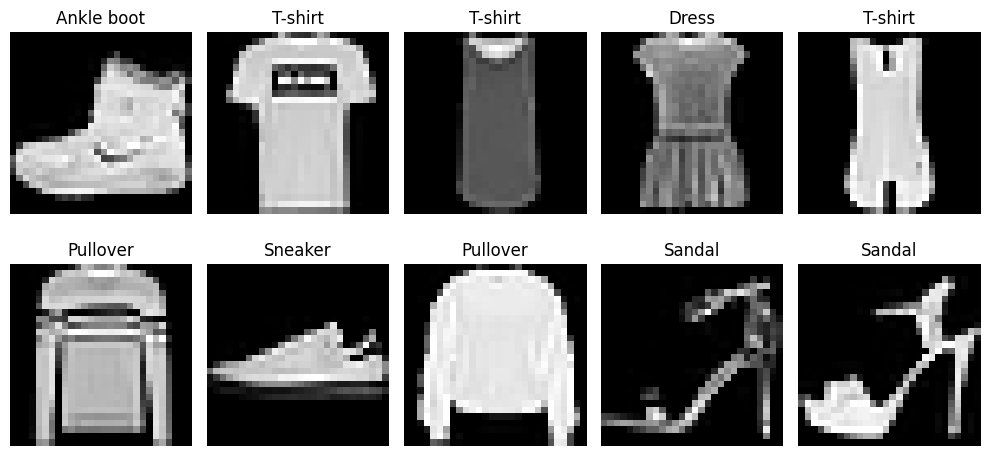

In [17]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Pre-processing

Pixel values are normalised to the range between 0 and 1 to improve optimisation stability.  
A validation set is also created from the training data to monitor model performance.

In [18]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_valid = X_train[:5000]
X_train_small = X_train[5000:]

y_valid = y_train[:5000]
y_train_small = y_train[5000:]

print("Training subset:", X_train_small.shape)
print("Validation subset:", X_valid.shape)

Training subset: (55000, 28, 28)
Validation subset: (5000, 28, 28)


## Neural Network Architecture

A deep fully connected neural network is used for classification.  
The same architecture is kept constant while only the activation function is changed.  
This allows fair comparison of learning behaviour.

A Flatten layer converts each 28 x 28 image into a one-dimensional feature vector.

In [19]:
def build_model(act):

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(256, activation=act),
        Dense(128, activation=act),
        Dense(64, activation=act),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## Training Models with Different Activation Functions

Three neural networks are trained using sigmoid, tanh and ReLU activation functions.  
All other parameters remain constant to ensure a fair experimental comparison.

In [20]:
activations = ["sigmoid", "tanh", "relu"]
histories = {}
models = {}

for act in activations:
    print("Training model with", act)
    model = build_model(act)
    history = model.fit(
        X_train_small, y_train_small,
        epochs=10,
        validation_data=(X_valid, y_valid),
        verbose=1
    )
    models[act] = model
    histories[act] = history

Training model with sigmoid
Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7780 - loss: 0.6487 - val_accuracy: 0.8570 - val_loss: 0.4059
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8586 - loss: 0.3929 - val_accuracy: 0.8724 - val_loss: 0.3504
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8731 - loss: 0.3499 - val_accuracy: 0.8784 - val_loss: 0.3273
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8821 - loss: 0.3236 - val_accuracy: 0.8846 - val_loss: 0.3170
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8888 - loss: 0.3038 - val_accuracy: 0.8868 - val_loss: 0.3117
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8950 - loss: 0.2876 - val_accuracy: 0.8894 - val_loss: 0.3077
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9000 - loss: 0.2725 - val_accuracy: 0.8924 - val_loss: 0.3048
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - 

## Training Loss Comparison

The training loss curves help illustrate how quickly each model converges during learning.

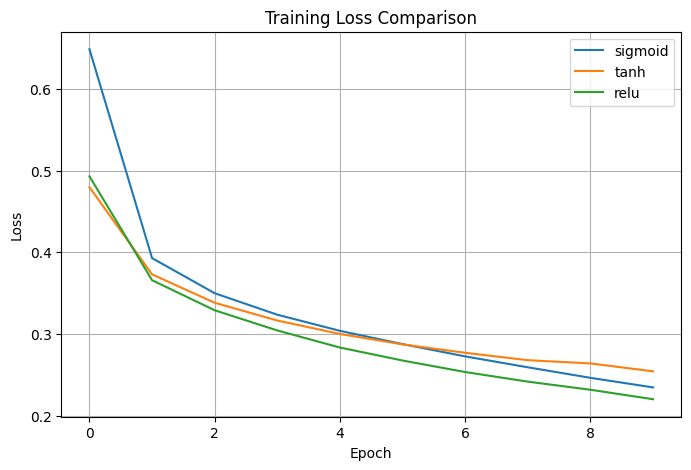

In [21]:
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(histories[act].history["loss"], label=act)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Validation Accuracy Comparison

Validation accuracy indicates how well each model performs on unseen data.

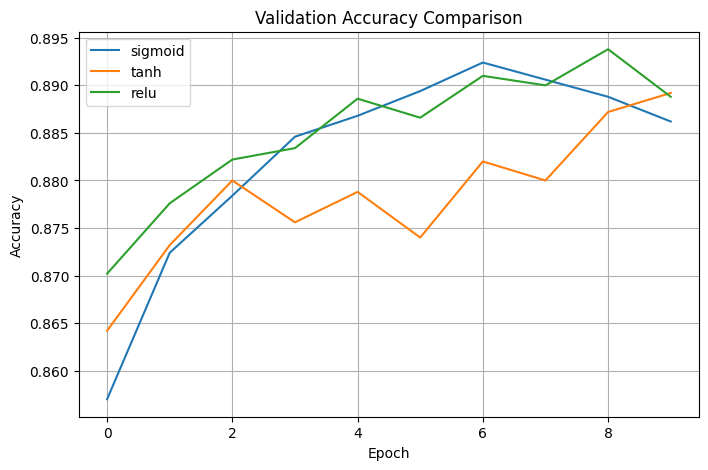

In [23]:
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(histories[act].history["val_accuracy"], label=act)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Final Test Evaluation

In [24]:
results = {}

for act in activations:
    test_loss, test_acc = models[act].evaluate(X_test, y_test, verbose=0)
    results[act] = [test_loss, test_acc]

import pandas as pd
results_df = pd.DataFrame(results, index=["Test Loss", "Test Accuracy"]).T
results_df

,Test Loss,Test Accuracy
sigmoid,0.357904,0.8736
tanh,0.347306,0.8764
relu,0.363829,0.8808


## Discussion of Results

The experiment shows that activation functions significantly influence learning behaviour.  
Sigmoid activation results in slower convergence because gradient values become smaller in deeper layers.  
Tanh provides slightly improved stability due to zero-centred outputs.  
ReLU demonstrates faster convergence and higher validation accuracy because it maintains stronger gradient signals.

These observations support the theoretical explanation of the vanishing gradient problem discussed in the tutorial.

## Conclusion

This notebook demonstrated how activation functions affect deep neural network training.  
The results show that ReLU generally achieves faster convergence and better performance compared to sigmoid and tanh in this experiment.

## References

Goodfellow, I., Bengio, Y. and Courville, A. (2016) Deep Learning. MIT Press.  
LeCun, Y., Bengio, Y. and Hinton, G. (2015) Deep learning. Nature.  
Chollet, F. (2021) Deep Learning with Python. Manning Publications.

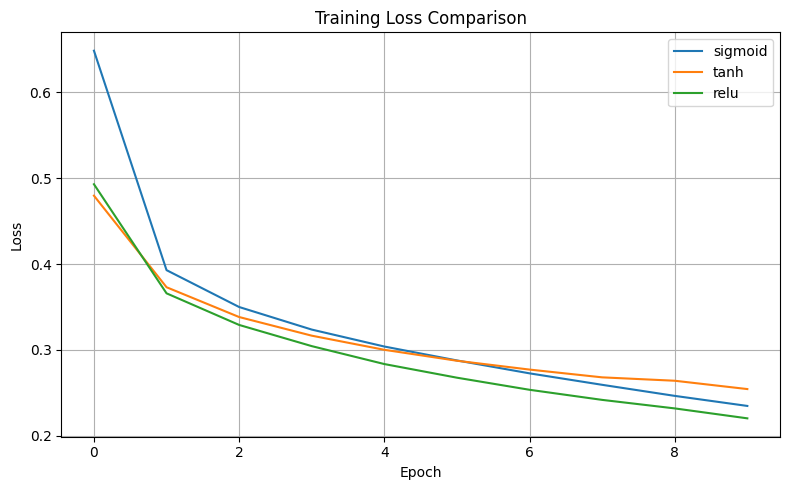

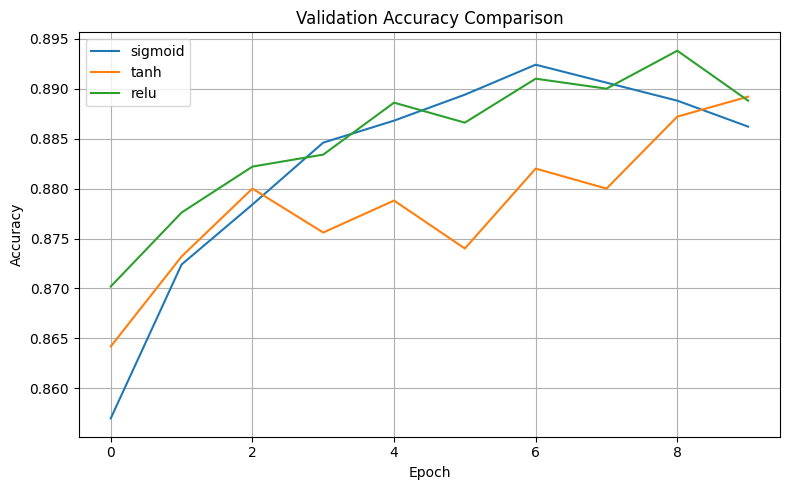

In [26]:
# Save training loss plot
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(histories[act].history["loss"], label=act)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss_comparison.png", dpi=300)
plt.show()


# Save validation accuracy plot
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(histories[act].history["val_accuracy"], label=act)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("validation_accuracy_comparison.png", dpi=300)
plt.show()